<h1> Section 1 - Introduction</h1>

This project predicts house sale prices using the Kaggle House Prices - Advanced Regression Techniques dataset. The dataset contains 1460 houses across 81 features describing physical qualities, size, location and condition of residential properties in Ames, Iowa.

The goal is to build a regression model that accurately predicts SalePrice given a house's features, and to compare three approaches Linear Regression, Ridge, and LASSO to find the most effective model.

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

<h1> Section 2 - Data Exploration </h1>

The dataset contains 1460 houses and 81 columns. Key observations:

Several columns had significant missing data - PoolQC (1453), MiscFeature (1406), Alley (1369) - indicating most houses simply don't have these features
SalePrice was right-skewed with a mean of $180,921 and a max of $755,000
Strongest correlations with SalePrice: OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64)
43 columns contained text (categorical) data requiring conversion before modelling

In [5]:
print(f"Training Data: {train.shape} \nTesting Data: {test.shape}")

Training Data: (1460, 81) 
Testing Data: (1459, 80)


In [6]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
train.dtypes.to_frame(name='Data Type')

,Data Type
Id,int64
MSSubClass,int64
MSZoning,str
LotFrontage,float64
LotArea,int64
Street,str
Alley,str
LotShape,str
LandContour,str
Utilities,str


In [8]:
train.isna().sum().sort_values(ascending=False).to_frame(name='Missing Values')

,Missing Values
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [9]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

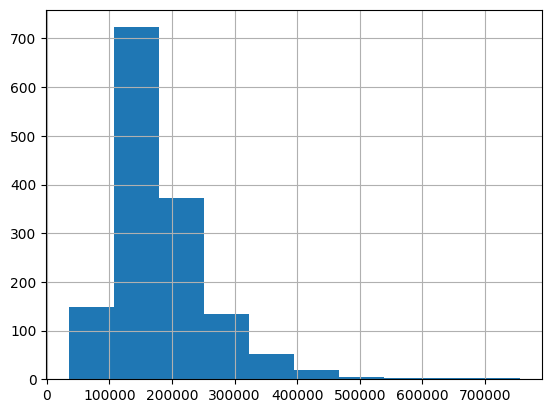

In [10]:
train['SalePrice'].hist()

In [11]:
train.duplicated().sum()

np.int64(0)

In [12]:
train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [13]:
missing = train.isnull().sum()
missing = missing[missing > 0]
pd.DataFrame({'missing': missing, 'dtype': train[missing.index].dtypes}).sort_values(by='missing', ascending=False)

,missing,dtype
PoolQC,1453,str
MiscFeature,1406,str
Alley,1369,str
Fence,1179,str
MasVnrType,872,str
FireplaceQu,690,str
LotFrontage,259,float64
GarageType,81,str
GarageYrBlt,81,float64
GarageFinish,81,str


<h1> Section 3 - Data Cleaning </h1>

Several cleaning steps were applied before modelling:

Missing values - Categorical columns with high missingness (PoolQC, Alley, Fence etc.) were filled with "None" because absence means the house simply doesn't have that feature. Numerical columns (LotFrontage, MasVnrArea) were filled with the median to avoid distorting the distribution. One row with a missing Electrical value was dropped.

Sparse columns - Columns where more than 80% of values were missing were dropped entirely. A column that empty gives the model almost nothing to learn from.

Target transformation - SalePrice was log-transformed because the original distribution was right-skewed, with a small number of very expensive houses pulling the tail. Linear regression assumes a normally distributed target, so the log transform made the distribution more suitable for modelling.

Encoding - All categorical text columns were converted to binary 0/1 columns using pd.get_dummies(), expanding the dataset from 81 to 260 features.

In [14]:
y = train['SalePrice']
X = train.drop(columns=['SalePrice', 'Id'])

<Axes: >

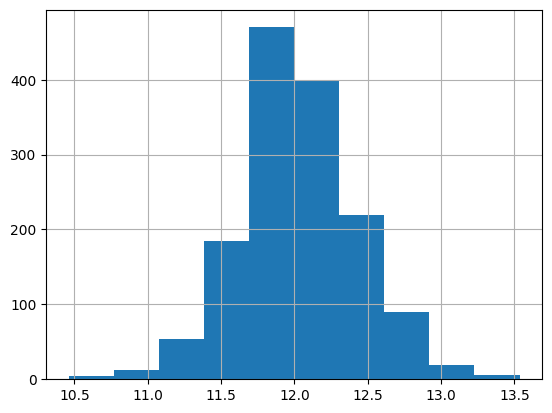

In [15]:
y = np.log(train['SalePrice'])
y.hist()

In [16]:
none_cols = [col for col in X.columns if (X[col].dtype == 'string' or X[col].dtype == 'object') and X[col].isnull().sum() > 0]

median_cols = [col for col in X.columns if X[col].dtype != 'string' and X[col].dtype != 'object' and X[col].isnull().sum() > 0]

for col in none_cols:
    X[col] = X[col].fillna('None')

for col in median_cols:
    X[col] = X[col].fillna(X[col].median())

In [17]:
thresh = len(X) * 0.8
X = X.dropna(thresh=thresh, axis=1 )

In [18]:
def group_rare_categories(df, col, threshold=10, new_col_suffix='_grouped'):
    """
    Groups categories with fewer than `threshold` occurrences into 'Other'.
    Keeps the original column untouched; creates a new column instead.
    """
    counts = df[col].value_counts()
    rare_categories = counts[counts < threshold].index
    
    new_col = col + new_col_suffix
    df[new_col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
    
    print(f"{col}: grouped {len(rare_categories)} rare categories into 'Other' "
          f"({counts[rare_categories].sum()} rows affected)")
    
    return df

In [19]:
X['HasPool'] = (X['PoolQC'] != "None").astype(int)
X = X.drop(columns=['PoolQC'])
X = group_rare_categories(X, 'RoofMatl', threshold=10)
X = group_rare_categories(X, 'Electrical', threshold=10)
X = group_rare_categories(X, 'MiscFeature', threshold = 10)

X = X.drop(columns=['RoofMatl', 'Electrical', 'MiscFeature'])  # drop originals only


RoofMatl: grouped 6 rare categories into 'Other' (15 rows affected)
Electrical: grouped 3 rare categories into 'Other' (5 rows affected)
MiscFeature: grouped 3 rare categories into 'Other' (5 rows affected)


In [20]:
print(X['RoofMatl_grouped'].value_counts())
print(X['MiscFeature_grouped'].value_counts())
print(X['Electrical_grouped'].value_counts())
print(X['HasPool'].value_counts())

RoofMatl_grouped
CompShg    1434
Other        15
Tar&Grv      11
Name: count, dtype: int64
MiscFeature_grouped
None     1406
Shed       49
Other       5
Name: count, dtype: int64
Electrical_grouped
SBrkr    1334
FuseA      94
FuseF      27
Other       5
Name: count, dtype: int64
HasPool
0    1453
1       7
Name: count, dtype: int64


In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
print(X.isnull().sum().sum())   
 

0


In [23]:
print(X.shape)                 

(1460, 249)


In [24]:
print(y.isnull().sum())   

0


<h1>Section 4 - Modelling </h1>

Three regression models were trained on the cleaned dataset using an 80/20 train/test split.

Linear Regression finds the best fit through the data by minimising prediction errors across all 260 features simultaneously. It assigns a weight to every feature and makes no assumptions about which features matter more than others.
R²: 0.920 | RMSE: $24,738

Ridge Regression works like linear regression but adds a penalty for large feature weights, preventing any single feature from dominating the model. It keeps all features but shrinks their influence. Alpha=20 was selected using cross-validation.
R²: 0.919 | RMSE: $25,297

LASSO Regression applies a stricter penalty that pushes weak feature weights all the way to zero, automatically removing irrelevant features. Of the 260 features, LASSO selected only 79 as meaningful. Alpha was selected using cross-validation on a log scale with scaled features.
R²: 0.901 | RMSE: $27,574

<h3>Linear Regression</h3>

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred = np.exp(y_pred)

mse = mean_squared_error(np.exp(y_test), y_pred)
r2 = r2_score(np.exp(y_test), y_pred)
rmse = np.sqrt(mse)





In [26]:
print(f"Linear Regression - Mean Squared Error: {mse}")
print(f"Linear Regression - R-squared: {r2}")
print(f"Linear Regression - Root Mean Squared Error: {rmse}")

Linear Regression - Mean Squared Error: 611975868.9004464
Linear Regression - R-squared: 0.920215144392813
Linear Regression - Root Mean Squared Error: 24738.14602795542


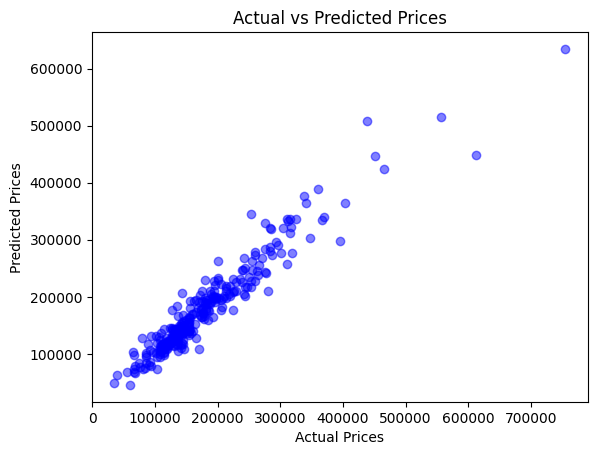

In [27]:
plt.scatter(np.exp(y_test), y_pred, marker='o', color='blue', alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [28]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coefficients)

                       feature   coefficient
36                     HasPool -3.071614e+00
92             Condition2_PosN -6.628770e-01
93             Condition2_RRAe -5.120955e-01
216              GarageQual_Po -4.611034e-01
213              GarageQual_Fa -4.272942e-01
221              GarageCond_Po  3.897871e-01
214              GarageQual_Gd -3.894550e-01
217              GarageQual_TA -3.731715e-01
37                 MSZoning_FV  3.634003e-01
197             Functional_Sev -3.539699e-01
38                 MSZoning_RH  3.511732e-01
91             Condition2_PosA  3.461992e-01
39                 MSZoning_RL  3.347522e-01
40                 MSZoning_RM  3.197195e-01
193            Functional_Maj2 -3.087465e-01
50            Utilities_NoSeWa -2.832788e-01
222              GarageCond_TA  2.779103e-01
218              GarageCond_Fa  2.660958e-01
89            Condition2_Feedr  2.620604e-01
219              GarageCond_Gd  2.492009e-01
66        Neighborhood_MeadowV -2.290205e-01
207       

In [29]:
roofmatl_cols = [col for col in X.columns if col.startswith('RoofMatl_')]
print(X[roofmatl_cols].sum())

poolqc_cols = [col for col in X.columns if col.startswith('PoolQC_')]
print(X[poolqc_cols].sum())

electrical_cols = [col for col in X.columns if col.startswith('Electrical_')]
print(X[electrical_cols].sum())

RoofMatl_grouped_Other      15
RoofMatl_grouped_Tar&Grv    11
dtype: int64
Series([], dtype: float64)
Electrical_grouped_FuseF      27
Electrical_grouped_Other       5
Electrical_grouped_SBrkr    1334
dtype: int64



<h3> Ridge regression</h3>

In [30]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [31]:
from sklearn.linear_model import RidgeCV


alphas = [0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 500, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train,y_train)

print("Best alpha:", ridge_cv.alpha_)

Best alpha: 20.0


In [32]:
model = Ridge(alpha=20)

model.fit(X_train, y_train)

y_pred_ridge = model.predict(X_test)

np.exp(y_pred_ridge)

mse_ridge = mean_squared_error(np.exp(y_test), np.exp(y_pred_ridge))
r2_ridge = r2_score(np.exp(y_test), np.exp(y_pred_ridge))
rmse_ridge = np.sqrt(mse_ridge)

In [33]:
print(f"Ridge Regression - Mean Squared Error: {mse_ridge}")
print(f"Ridge Regression - R-squared: {r2_ridge}")  
print(f"Ridge Regression - Root Mean Squared Error: {rmse_ridge}")

Ridge Regression - Mean Squared Error: 680385061.4540876
Ridge Regression - R-squared: 0.9112964633998794
Ridge Regression - Root Mean Squared Error: 26084.191792234767


Text(0.5, 1.0, 'Actual vs Predicted Prices (Ridge Regression)')

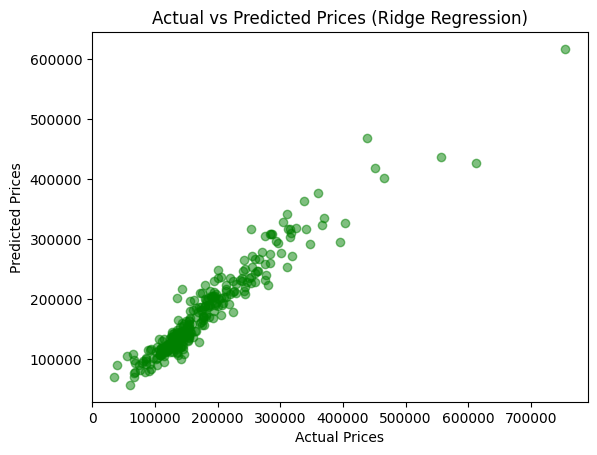

In [34]:
plt.scatter(np.exp(y_test), np.exp(y_pred_ridge), marker='o', color='green', alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Ridge Regression)")

# Ridge (alpha=20): R²=0.913, RMSE=$25,847
# LinearRegression: R²=0.920, RMSE=$24,738
# Conclusion: Ridge does not improve over baseline on this dataset
# likely because feature engineering already reduced multicollinearity

<h3>LASSO CV</h3>

In [65]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fit LassoCV
alphas = np.logspace(-4, 1, 200)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+01])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [66]:
# 3. Check selected features
kept = np.sum(lasso_cv.coef_ != 0)
zeroed = np.sum(lasso_cv.coef_ == 0)

print(f"Best alpha: {lasso_cv.alpha_}")
print(f"Kept {kept} features")
print(f"Zeroed {zeroed} features")

Best alpha: 0.006080224261649427
Kept 79 features
Zeroed 170 features


In [67]:
# 4. Predict and invert log transformation
y_pred_lasso = lasso_cv.predict(X_test_scaled)

# Convert back from log scale to real dollar values
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(y_pred_lasso)

# 5. Calculate metrics on dollar values
mse_lasso = mean_squared_error(y_test_exp, y_pred_exp)
r2_lasso = r2_score(y_test_exp, y_pred_exp)
rmse_lasso = np.sqrt(mse_lasso)

print(f"Lasso Regression - Mean Squared Error: {mse_lasso}")
print(f"Lasso Regression - R-squared: {r2_lasso}")
print(f"Lasso Regression - Root Mean Squared Error: {rmse_lasso}")

Lasso Regression - Mean Squared Error: 760335187.8494565
Lasso Regression - R-squared: 0.9008731614130022
Lasso Regression - Root Mean Squared Error: 27574.176104635593


<h1>Section 5 - Comparison & Conclusion</h1>
Linear Regression and Ridge performed almost identically, both achieving R²=0.92 and RMSE around $25,000. This means on average the model predicts house prices within $25,000 reasonable given a price range of $34,900 to $755,000.

LASSO reduced the feature set from 260 to 79 with only a small drop in performance, which demonstrates that a large portion of the features carry redundant information. However since accuracy is the priority here, Ridge is the recommended model it matches Linear Regression's performance while being more robust to unseen data.

C:\Users\nifem\AppData\Local\Temp\ipykernel_20640\2619505915.py:6: RuntimeWarning: overflow encountered in exp
  ax.scatter(np.exp(y_test), np.exp(pred), alpha=0.5)


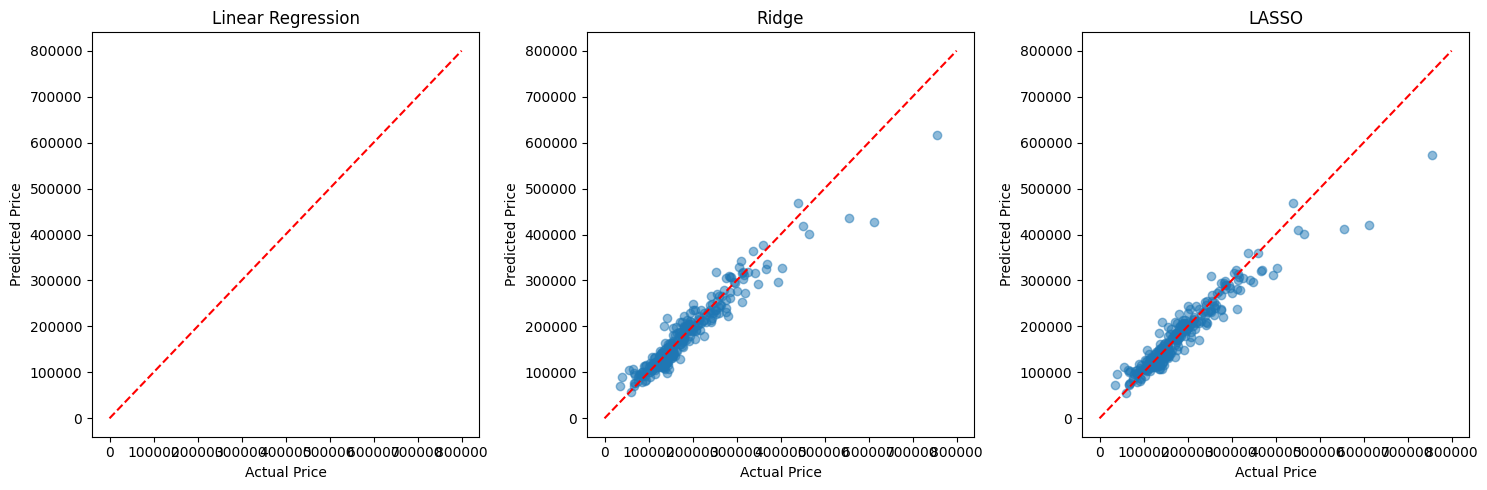

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['Linear Regression', 'Ridge', 'LASSO']
predictions = [y_pred, y_pred_ridge, y_pred_lasso]

for ax, name, pred in zip(axes, models, predictions):
    ax.scatter(np.exp(y_test), np.exp(pred), alpha=0.5)
    ax.plot([0, 800000], [0, 800000], 'r--')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.tight_layout()
plt.show()